In [1]:
import networkx as nx
import numpy as np
import torch
from torch import nn
from torchvision import transforms
from torchvision.datasets import MNIST

import decent_bench.utils.interoperability as iop
from decent_bench import benchmark
from decent_bench.agents import Agent
from decent_bench.algorithms import decentralized
from decent_bench.algorithms.utils import pytorch_initialization
from decent_bench.costs import PyTorchCost
from decent_bench.datasets import PyTorchDatasetHandler
from decent_bench.metrics import metric_library as ml
from decent_bench.networks import P2PNetwork
from decent_bench.utils.pytorch_utils import ArgmaxActivation, SimpleLinearModel
from decent_bench.utils.types import SupportedDevices, SupportedFrameworks

[04/03/26 04:39:38] INFO     No checkpoint manager provided, running benchmark without            ]8;id=242897;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py\_benchmark.py]8;;\:]8;id=6686;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py#267\267]8;;\
                             checkpointing. Progress cannot be resumed if interrupted.                             

                    INFO     Starting benchmark execution                                         ]8;id=887730;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py\_benchmark.py]8;;\:]8;id=786259;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py#353\353]8;;\

Output()

[04/03/26 04:40:00] INFO     Benchmark execution complete, thanks for using decent-bench          ]8;id=544972;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py\_benchmark.py]8;;\:]8;id=841788;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py#371\371]8;;\

Output()

Output()

[04/03/26 04:40:04] INFO     Empirical-risk cost functions are in use. Compute counters increment by  ]8;id=374123;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=164639;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#67\67]8;;\
                             the number of samples processed in each method call, which can lead to                
                             large raw counts. Applying scaling factor of 'scale_compute=1.0' to ['nr              
                             gradient calls'] metrics for display.                                                 

                    INFO                                                                              ]8;id=293522;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=783996;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#98\98]8;;\
                             +-------------------------+---------------------+---------------------+               
                             | Metric (statistic)      | ProxSkip            | ProxSkip            |               
                             +=========================+=====================+=====================+               
                             | consensus error (min)   | 2.57e-01 ± 0.00e+00 | 1.92e-03 ± 0.00e+00 |               
                             +-------------------------+---------------------+---------------------+               
                             | consensus error (avg)   | 5.61e-01 ± 0.00e+00 | 2.58e-03 ± 0.00e+00 |               
                             +-------------------------+---------------------+---------------------+               
                             | consensus error (max)   | 7.35e-01 ± 0.00e+00 | 3.14e-03 ± 0.00e+00 |               
                             +-------------------------+---------------------+---------------------+               
                             | nr gradient calls (avg) | 5.12e+05 ± 0.00e+00 | 5.12e+05 ± 0.00e+00 |               
                             +-------------------------+---------------------+---------------------+               
                             | nr gradient calls (sum) | 2.56e+06 ± 0.00e+00 | 2.56e+06 ± 0.00e+00 |               
                             +-------------------------+---------------------+---------------------+               
                             | nr sent messages (avg)  | 4.40e+02 ± 0.00e+00 | 2.01e+03 ± 0.00e+00 |               
                             +-------------------------+---------------------+---------------------+               
                             | nr sent messages (sum)  | 2.20e+03 ± 0.00e+00 | 1.00e+04 ± 0.00e+00 |               
                             +-------------------------+---------------------+---------------------+               
                             | accuracy (min)          | 55.36% ± 0.00%      | 67.82% ± 0.00%      |               
                             +-------------------------+---------------------+---------------------+               
                             | accuracy (avg)          | 67.69% ± 0.00%      | 67.93% ± 0.00%      |               
                             +-------------------------+---------------------+---------------------+               
                             | accuracy (max)          | 85.66% ± 0.00%      | 68.00% ± 0.00%      |               
                             +-------------------------+---------------------+---------------------+               
                             | precision (min)         | 55.36% ± 0.00%      | 67.82% ± 0.00%      |               
                             +-------------------------+---------------------+---------------------+               
                             | precision (avg)         | 67.69% ± 0.00%      | 67.93% ± 0.00%      |               
                             +-------------------------+---------------------+---------------------+               
                             | precision (max)         | 85.66% ± 0.00%      | 68.00% ± 0.00%      |               
                             +-------------------------+---------------------+---------------------+               
                             | recall (min)            | 55.36% ± 0.00%      | 67.82% ± 0.00%      |               
                             +-------------------------+---------------------+---------------------+               
                             | recall (avg)            | 67.69% ± 0.00%      | 67.93% ± 0.00%    

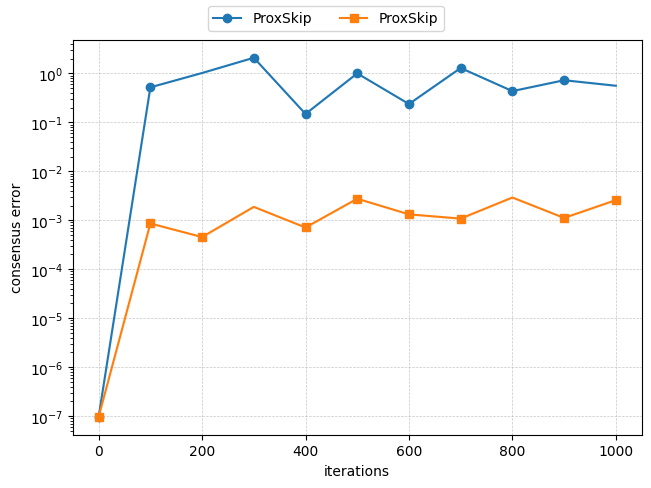

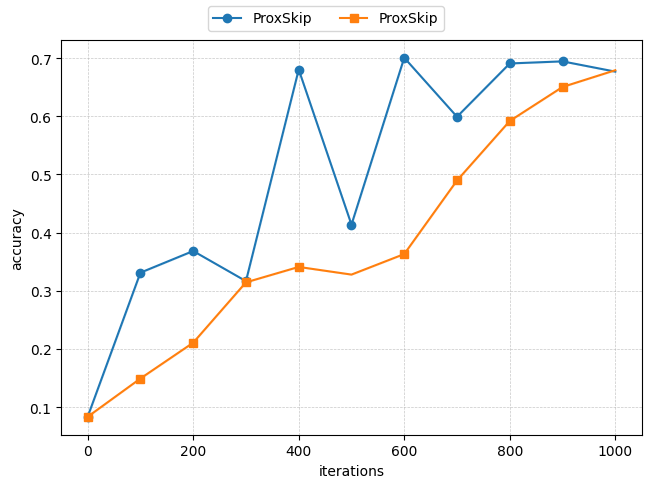

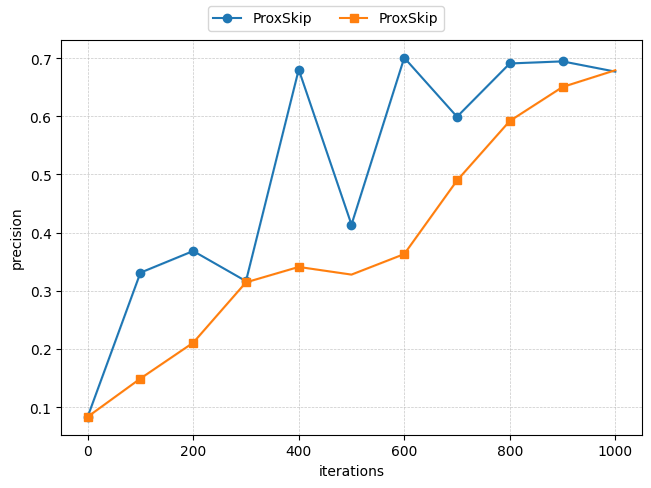

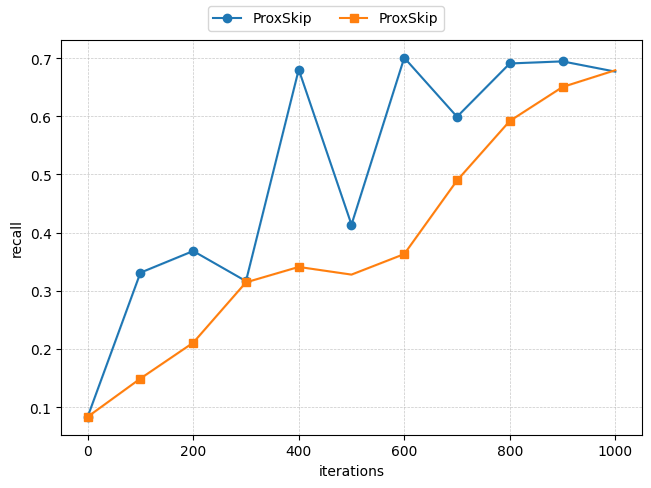

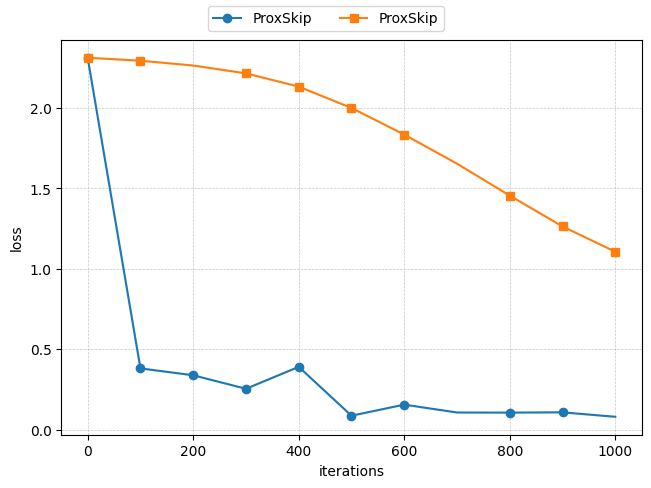

In [2]:
iterations = 1000
n_trials = 1
n_agents = 5
n_neighbors = 4
state_snapshot_period = 100
samples_per_partition = 1000
heterogeneity = True
targets_per_partition = 2
batch_sizes = [32, 64, 128]
step_sizes = [0.01, 0.001]
local_steps = [1, 5, 10]
device = SupportedDevices.CPU
use_dataloader = False
compile_model = False
opt_cls = torch.optim.Adam
opt_kwargs = None
sched_cls = None  # torch.optim.lr_scheduler.StepLR
sched_kwargs = {"step_size": 100, "gamma": 0.9}
iop.set_seed(47)

table_metrics = [
    ml.ConsensusError([min, np.average, max]),
    ml.GradientCalls([np.average, sum]),
    ml.SentMessages([np.average, sum]),
    ml.Accuracy([min, np.average, max], fmt=".2%"),
    ml.Precision([min, np.average, max], fmt=".2%"),
    ml.Recall([min, np.average, max], fmt=".2%"),
    ml.Loss([min, np.average, max]),
]

plot_metrics = [
    [ml.ConsensusError([], x_log=False, y_log=True)],
    [ml.Accuracy([], x_log=False, y_log=False)],
    [ml.Precision([], x_log=False, y_log=False)],
    [ml.Recall([], x_log=False, y_log=False)],
    [ml.Loss([], x_log=False, y_log=False)],
]

torch_device = iop.device_to_framework_device(device, SupportedFrameworks.PYTORCH)
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
mnist_train = MNIST(root="data", train=True, download=True, transform=transform, target_transform=torch.tensor)
mnist_test = MNIST(root="data", train=False, download=True, transform=transform, target_transform=torch.tensor)

train_dataset = PyTorchDatasetHandler(
    torch_dataset=mnist_train,
    n_features=28 * 28,
    n_targets=10,
    n_partitions=n_agents,
    samples_per_partition=samples_per_partition,
    heterogeneity=heterogeneity,
    targets_per_partition=targets_per_partition,
)
test_dataset = PyTorchDatasetHandler(
    torch_dataset=mnist_test,
    n_features=28 * 28,
    n_targets=10,
    n_partitions=n_agents,
    samples_per_partition=samples_per_partition,
    heterogeneity=heterogeneity,
    targets_per_partition=targets_per_partition,
)


def model_generator() -> torch.nn.Module:
    """Generate a simple linear model for the MNIST dataset."""
    return SimpleLinearModel(
        input_size=train_dataset.n_features,
        hidden_sizes=[32, 16],
        output_size=train_dataset.n_targets,
    )


costs = [
    PyTorchCost(
        dataset=p,
        model=model_generator(),
        loss_fn=nn.CrossEntropyLoss(),
        final_activation=ArgmaxActivation(),
        batch_size=512,
        max_batch_size=512,
        device=device,
        use_dataloader=use_dataloader,
        dataloader_kwargs={} if device == SupportedDevices.GPU else {"pin_memory": True},
        compile_model=compile_model,
        compile_kwargs={"mode": "reduce-overhead"},
    )
    for p in train_dataset.get_partitions()
]
agents = [Agent(i, cost, state_snapshot_period=state_snapshot_period) for i, cost in enumerate(costs)]
graph = nx.random_regular_graph(d=n_neighbors, n=n_agents, seed=iop.get_seed())
network = P2PNetwork(graph=graph, agents=agents)
problem = benchmark.BenchmarkProblem(
    network=network,
    test_data=list(test_dataset.get_datapoints()),  # hacky fix to make it pickleable
)
x0 = pytorch_initialization(network, all_same=True)
algorithms = [
    decentralized.ProxSkip(
        iterations=iterations,
        x0=x0,
        step_size=0.1,
        aux_step_size=0.1,
        comm_probability=0.1,
    ),
    decentralized.ProxSkip(
        iterations=iterations,
        x0=x0,
        step_size=0.01,
        aux_step_size=0.1,
        comm_probability=0.5,
    ),
    # # decentralized.KGT(
    #     iterations=iterations,
    #     x0=x0,
    #     step_size=0.01,
    #     aux_step_size=0.1,
    #     local_steps=10,
    # )
]
algorithms = sorted(algorithms, key=lambda alg: alg.name)
result = benchmark.benchmark(
    algorithms=algorithms,
    benchmark_problem=problem,
    n_trials=n_trials,
    show_speed=True,
    show_trial=True,
)

metric_result = benchmark.compute_metrics(
    benchmark_result=result,
    table_metrics=table_metrics,
    plot_metrics=plot_metrics,
)

benchmark.display_metrics(
    metrics_result=metric_result,
    show_plots=True,
)

In [3]:
import pandas as pd

metrics = {"accuracy", "loss", "consensus error", "nr gradient calls"}
data = []
for alg, table in metric_result.table_results.items():
    alg_data = {"algorithm": alg.name}
    for metric, values in table.items():
        if metric.table_description not in metrics:
            continue
        for statistic, value in values.items():
            if statistic != "avg":
                continue
            alg_data[metric.table_description] = value[0]
            alg_data[f"{metric.table_description} std"] = value[1]
    data.append(alg_data)
df = pd.DataFrame(data)

In [4]:
df

,algorithm,consensus error,consensus error std,nr gradient calls,nr gradient calls std,accuracy,accuracy std,loss,loss std
0,ProxSkip,0.561005,0.0,512000.0,0.0,0.67688,0.0,0.079341,0.0
1,ProxSkip,0.002580,0.0,512000.0,0.0,0.67928,0.0,1.105412,0.0


In [4]:
df

,algorithm,consensus error,consensus error std,nr gradient calls,nr gradient calls std,accuracy,accuracy std,loss,loss std
0,K-GT,7.543038e-08,0.0,2560000.0,0.0,0.105,0.0,2.302834,0.0
